# Student Habits & Academic Performance — Exploratory Data Analysis

**Target variable:** `exam_score` (continuous, 0–100)
**Dataset size:** 1,000 students × 16 columns
**Source:** [Kaggle — jayaantanaath/student-habits-vs-academic-performance](https://www.kaggle.com/datasets/jayaantanaath/student-habits-vs-academic-performance)


## 1. Setup & Imports

In [4]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, f_oneway

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

# Output directory for figures (handy for embedding in the report)
FIG = Path("eda_figures")
FIG.mkdir(exist_ok=True)

## 2. Load the Dataset

In [5]:
LOCAL = Path("../data/raw/student_habits_performance.csv")

if LOCAL.exists():
    df = pd.read_csv(LOCAL)
    print(f"Loaded from local file: {LOCAL}")
else:
    import kagglehub
    from kagglehub import KaggleDatasetAdapter
    df = kagglehub.load_dataset(
        KaggleDatasetAdapter.PANDAS,
        "jayaantanaath/student-habits-vs-academic-performance",
        "student_habits_performance.csv",
    )
    print("Loaded from KaggleHub")

print(f"Shape: {df.shape}")
df.head()

Loaded from KaggleHub
Shape: (1000, 16)


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


## 3. Data Overview

### 3.1 Data Dictionary

| Column | Role | Type | Definition | Unit / Levels | Valid Range |
|---|---|---|---|---|---|
| `student_id` | Identifier | Nominal | Anonymised student key | — | `S1000`–`S1999` |
| `age` | Feature | Numeric (int) | Student age | years | 17 – 24 |
| `gender` | Feature | Nominal | Self-reported gender | Male / Female / Other | 3 levels |
| `study_hours_per_day` | Feature | Numeric (float) | Average daily study time | hours | 0.0 – 8.3 |
| `social_media_hours` | Feature | Numeric (float) | Average daily social-media use | hours | 0.0 – 7.2 |
| `netflix_hours` | Feature | Numeric (float) | Average daily streaming time | hours | 0.0 – 5.4 |
| `part_time_job` | Feature | Nominal | Holds a part-time job | Yes / No | binary |
| `attendance_percentage` | Feature | Numeric (float) | Class attendance | % | 56.0 – 100.0 |
| `sleep_hours` | Feature | Numeric (float) | Average nightly sleep | hours | 3.2 – 10.0 |
| `diet_quality` | Feature | Ordinal | Self-reported diet quality | Poor < Fair < Good | 3 levels |
| `exercise_frequency` | Feature | Numeric (int) | Weekly exercise sessions | sessions / week | 0 – 6 |
| `parental_education_level` | Feature | Ordinal | Highest parental education | High School < Bachelor < Master | 3 levels |
| `internet_quality` | Feature | Ordinal | Self-reported internet quality | Poor < Average < Good | 3 levels |
| `mental_health_rating` | Feature | Numeric (int) | Self-reported mental wellbeing | 1–10 scale | 1 – 10 |
| `extracurricular_participation` | Feature | Nominal | Participates in extracurriculars | Yes / No | binary |
| `exam_score` | **Target** | Numeric (float) | Final exam score | 0–100 scale | 18.4 – 100.0 |

### 3.2 Structural Summary

In [6]:
print(f"Observations: {df.shape[0]:,}")
print(f"Columns:      {df.shape[1]} (1 identifier + 14 features + 1 target)")
print()
print("Dtypes:")
print(df.dtypes)

Observations: 1,000
Columns:      16 (1 identifier + 14 features + 1 target)

Dtypes:
student_id                        object
age                                int64
gender                            object
study_hours_per_day              float64
social_media_hours               float64
netflix_hours                    float64
part_time_job                     object
attendance_percentage            float64
sleep_hours                      float64
diet_quality                      object
exercise_frequency                 int64
parental_education_level          object
internet_quality                  object
mental_health_rating               int64
extracurricular_participation     object
exam_score                       float64
dtype: object


### 3.3 Numeric Summary Statistics

In [7]:
df.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
age,1000.0,20.50,2.31,17.0,18.75,20.0,23.00,24.0
study_hours_per_day,1000.0,3.55,1.47,0.0,2.60,3.5,4.50,8.3
social_media_hours,1000.0,2.51,1.17,0.0,1.70,2.5,3.30,7.2
netflix_hours,1000.0,1.82,1.08,0.0,1.00,1.8,2.52,5.4
attendance_percentage,1000.0,84.13,9.40,56.0,78.00,84.4,91.02,100.0
sleep_hours,1000.0,6.47,1.23,3.2,5.60,6.5,7.30,10.0
exercise_frequency,1000.0,3.04,2.03,0.0,1.00,3.0,5.00,6.0
mental_health_rating,1000.0,5.44,2.85,1.0,3.00,5.0,8.00,10.0
exam_score,1000.0,69.60,16.89,18.4,58.48,70.5,81.32,100.0


## 4. Data Quality Assessment

### 4.1 Missing Values

In [8]:
miss = df.isnull().sum()
miss_pct = (miss / len(df) * 100).round(2)
miss_df = pd.DataFrame({"missing": miss, "percent": miss_pct})
miss_df = miss_df[miss_df["missing"] > 0].sort_values("missing", ascending=False)
miss_df

,missing,percent
parental_education_level,91,9.1


**Finding.** Only `parental_education_level` has missing values
(91 rows, 9.1 %); the other 15 columns are complete. Given the modest
proportion and that the feature is categorical, **mode imputation** is a
suitable strategy — it preserves the distribution and matches the
imputation used in the downstream training pipeline.

In [9]:
df["parental_education_level"] = df["parental_education_level"].fillna(
    df["parental_education_level"].mode()[0]
)
assert df.isnull().sum().sum() == 0
print("After imputation — total missing:", df.isnull().sum().sum())

After imputation — total missing: 0


### 4.2 Duplicate Records

Check both full-row duplicates and duplicate values of the unique
identifier.

In [10]:
print(f"Full-row duplicates:        {df.duplicated().sum()}")
print(f"Duplicate `student_id`s:    {df.duplicated(subset=['student_id']).sum()}")

Full-row duplicates:        0
Duplicate `student_id`s:    0


### 4.3 Outlier Detection (Tukey's IQR Rule)

For each numeric feature the inter-quartile range (IQR) and
flag values outside the Tukey fences `[Q1 − 1.5·IQR, Q3 + 1.5·IQR]` is computed. This
is a non-parametric method that does not assume normality.

In [11]:
numeric_for_outliers = [
    "age", "study_hours_per_day", "social_media_hours", "netflix_hours",
    "attendance_percentage", "sleep_hours", "exercise_frequency",
    "mental_health_rating", "exam_score",
]

outlier_records = []
for col in numeric_for_outliers:
    s = df[col]
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n = ((s < lo) | (s > hi)).sum()
    outlier_records.append({
        "feature": col,
        "Q1": round(q1, 2),
        "Q3": round(q3, 2),
        "lower_fence": round(lo, 2),
        "upper_fence": round(hi, 2),
        "n_outliers": int(n),
        "pct": round(100 * n / len(s), 2),
    })

outlier_df = pd.DataFrame(outlier_records).set_index("feature")
print(f"Total outlying cells across all numeric features: "
      f"{outlier_df['n_outliers'].sum()} "
      f"({100*outlier_df['n_outliers'].sum() / (len(df)*len(numeric_for_outliers)):.2f}% of numeric cells)")
print()
outlier_df

Total outlying cells across all numeric features: 23 (0.26% of numeric cells)



,Q1,Q3,lower_fence,upper_fence,n_outliers,pct
feature,,,,,,
age,18.75,23.00,12.38,29.38,0,0.0
study_hours_per_day,2.60,4.50,-0.25,7.35,7,0.7
social_media_hours,1.70,3.30,-0.70,5.70,5,0.5
netflix_hours,1.00,2.52,-1.29,4.81,4,0.4
attendance_percentage,78.00,91.03,58.46,110.56,3,0.3
sleep_hours,5.60,7.30,3.05,9.85,2,0.2
exercise_frequency,1.00,5.00,-5.00,11.00,0,0.0
mental_health_rating,3.00,8.00,-4.50,15.50,0,0.0
exam_score,58.48,81.33,24.20,115.60,2,0.2


## 5. Feature Engineering Rationale

Two derived features are introduced to capture trade-offs that the raw
variables encode only implicitly.

### 5.1 Motivation

A student's daily time is a **zero-sum allocation** between study,
sleep, paid work, and leisure activities (social media, streaming,
exercise). Univariate features capture absolute amounts of each
activity, but the academic literature on student performance
consistently identifies **competing time-use** as a stronger predictor
than any single activity in isolation. 

| Feature | Definition | Concept Captured |
|---|---|---|
| `total_screen_time` | `social_media_hours + netflix_hours` | Aggregate non-academic screen consumption |
| `study_to_leisure_ratio` | `study_hours_per_day / (total_screen_time + 0.1)` | Balance of academic effort against leisure consumption |

The `+ 0.1` term in the denominator is a small additive constant that
prevents division by zero for the small number of students who report
no leisure screen time; its effect on the ratio is negligible for
typical values.

### 5.2 Transformations Considered (and Not Applied)

In [12]:
df["total_screen_time"]      = df["social_media_hours"] + df["netflix_hours"]
df["study_to_leisure_ratio"] = df["study_hours_per_day"] / (df["total_screen_time"] + 0.1)

NUMERIC = [
    "age", "study_hours_per_day", "social_media_hours", "netflix_hours",
    "attendance_percentage", "sleep_hours", "exercise_frequency",
    "mental_health_rating", "total_screen_time", "study_to_leisure_ratio",
]
CATEGORICAL = [
    "gender", "part_time_job", "diet_quality", "parental_education_level",
    "internet_quality", "extracurricular_participation",
]
TARGET = "exam_score"

# Ordinal level ordering for cleaner plots
ORDER = {
    "diet_quality":             ["Poor", "Fair", "Good"],
    "parental_education_level": ["High School", "Bachelor", "Master"],
    "internet_quality":         ["Poor", "Average", "Good"],
}

print("Engineered features summary:")
df[["total_screen_time", "study_to_leisure_ratio"]].describe().round(2).T

Engineered features summary:


,count,mean,std,min,25%,50%,75%,max
total_screen_time,1000.0,4.33,1.60,0.2,3.30,4.4,5.40,10.1
study_to_leisure_ratio,1000.0,0.99,0.93,0.0,0.55,0.8,1.16,18.0


## 6. Target Variable — Distribution of Exam Scores

Before exploring relationships need to understand the target itself:
its shape, central tendency, and spread.

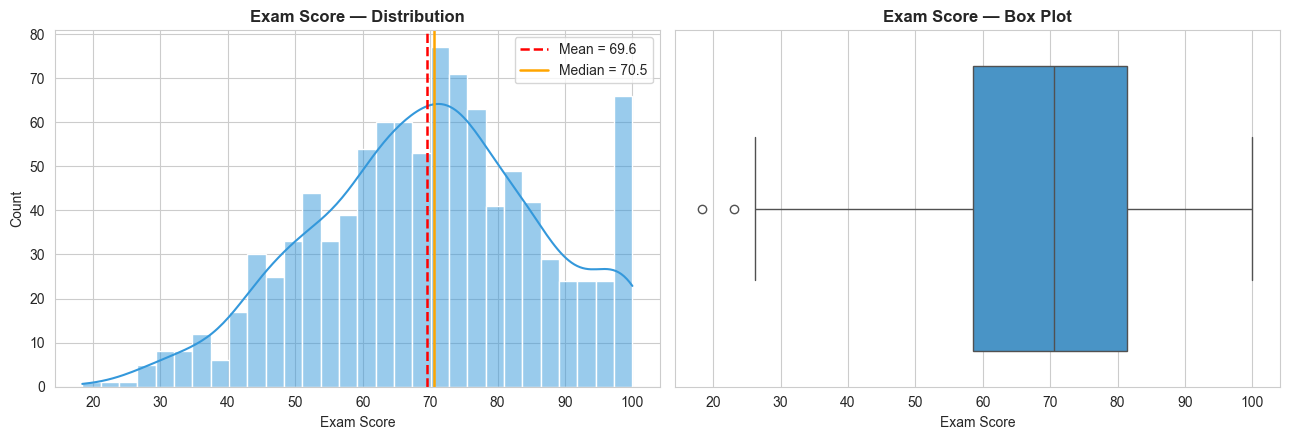

Mean:   69.60
Median: 70.50
Std:    16.89
Range:  18.4 – 100.0
Skew:   -0.156  (≈0 means symmetric)


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(df[TARGET], bins=30, kde=True, color="#3498db", ax=axes[0], edgecolor="white")
axes[0].axvline(df[TARGET].mean(),   color="red",    ls="--", lw=1.8, label=f"Mean = {df[TARGET].mean():.1f}")
axes[0].axvline(df[TARGET].median(), color="orange", ls="-",  lw=1.8, label=f"Median = {df[TARGET].median():.1f}")
axes[0].set_title("Exam Score — Distribution", fontweight="bold")
axes[0].set_xlabel("Exam Score")
axes[0].legend()

sns.boxplot(x=df[TARGET], ax=axes[1], color="#3498db")
axes[1].set_title("Exam Score — Box Plot", fontweight="bold")
axes[1].set_xlabel("Exam Score")

plt.tight_layout()
plt.savefig(FIG / "01_target_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"Mean:   {df[TARGET].mean():.2f}")
print(f"Median: {df[TARGET].median():.2f}")
print(f"Std:    {df[TARGET].std():.2f}")
print(f"Range:  {df[TARGET].min():.1f} – {df[TARGET].max():.1f}")
print(f"Skew:   {df[TARGET].skew():.3f}  (≈0 means symmetric)")

## 7. Univariate Analysis — Numerical Features

Univariate histograms with KDE overlay for every numeric feature. The
shape, skewness, and dynamic range of each feature inform later decisions
about scaling and outlier handling.

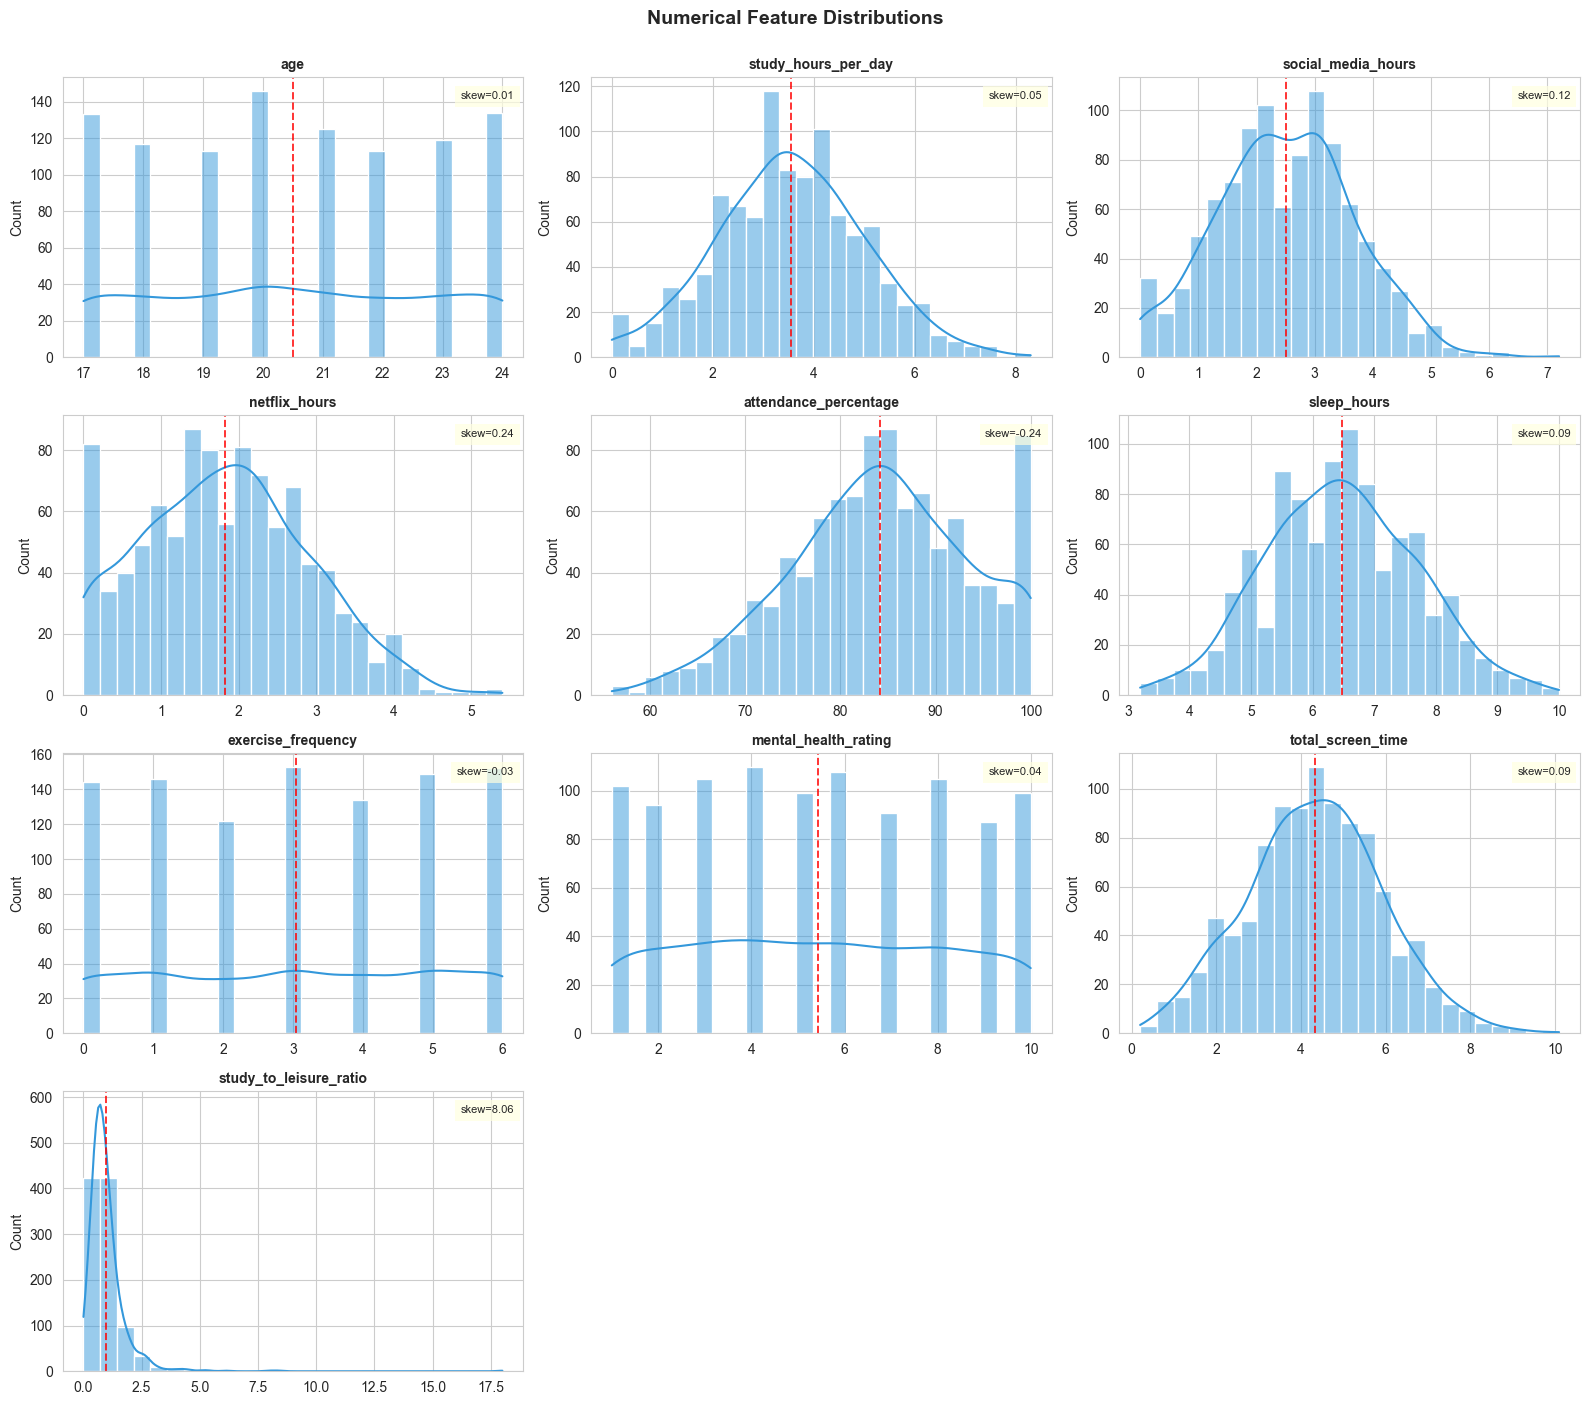

In [14]:
ncols, nrows = 3, (len(NUMERIC) + 2) // 3
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.5))
axes = axes.flatten()

for i, col in enumerate(NUMERIC):
    ax = axes[i]
    data = df[col].dropna()
    sns.histplot(data, kde=True, bins=25, ax=ax, color="#3498db", edgecolor="white")
    ax.axvline(data.mean(), color="red", ls="--", lw=1.4, alpha=0.8)
    ax.set_title(col, fontweight="bold", fontsize=10)
    ax.set_xlabel("")
    ax.text(0.98, 0.95, f"skew={data.skew():.2f}",
            transform=ax.transAxes, fontsize=8, ha="right", va="top",
            bbox=dict(facecolor="lightyellow", alpha=0.7, edgecolor="none"))

for j in range(len(NUMERIC), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Numerical Feature Distributions", fontsize=14, fontweight="bold", y=1.00)
plt.tight_layout()
plt.savefig(FIG / "02_numerical_distributions.png", dpi=120, bbox_inches="tight")
plt.show()

## 8. Univariate Analysis — Categorical Features

Class balance matters: a strongly imbalanced categorical can dominate or
disappear in downstream encoding.

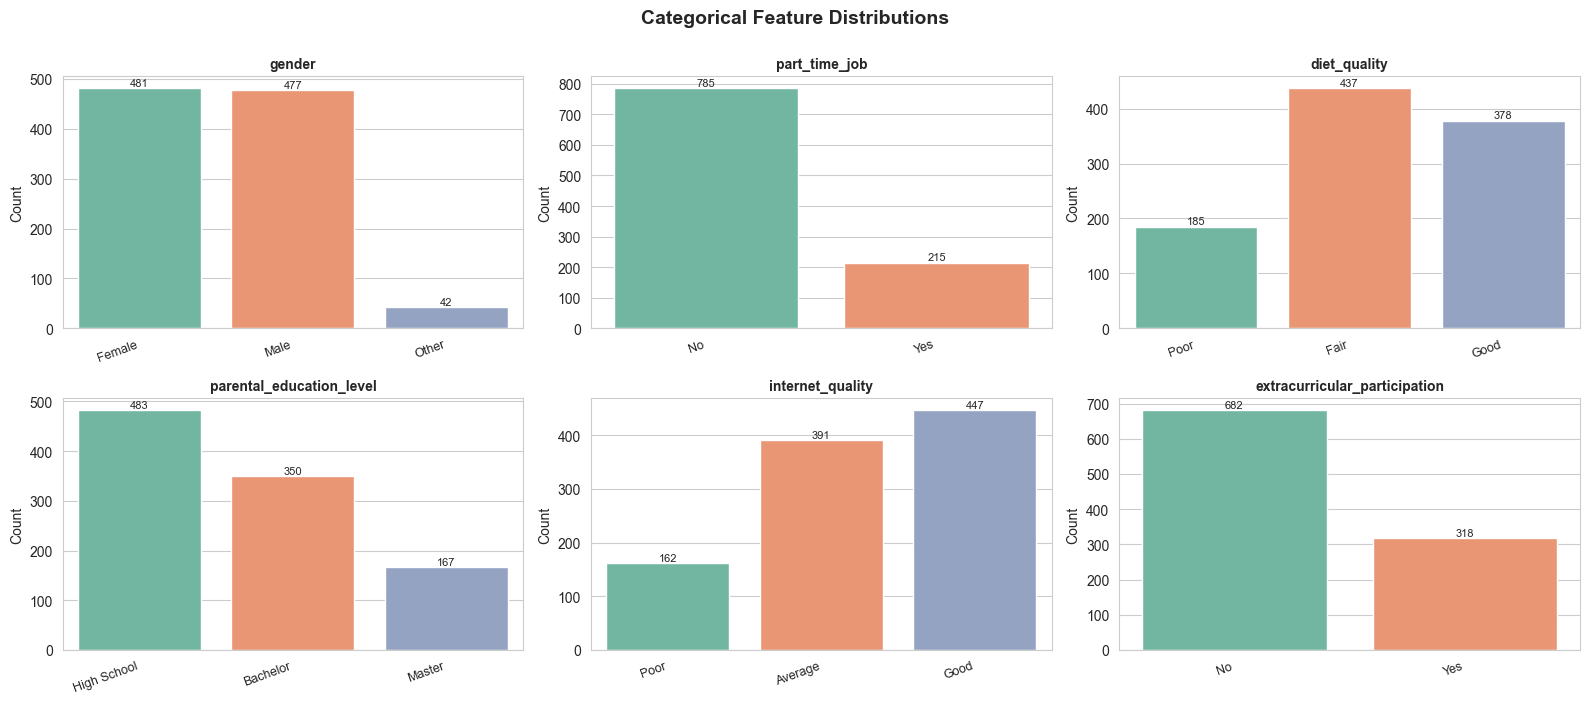

In [15]:
ncols, nrows = 3, (len(CATEGORICAL) + 2) // 3
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.5))
axes = axes.flatten()

for i, col in enumerate(CATEGORICAL):
    ax = axes[i]
    order = ORDER.get(col)
    counts = df[col].value_counts()
    if order:
        counts = counts.reindex(order)
    sns.barplot(x=counts.index, y=counts.values, ax=ax, palette="Set2")
    ax.set_title(col, fontweight="bold", fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("Count")
    plt.setp(ax.get_xticklabels(), rotation=20, ha="right", fontsize=9)
    for bar, val in zip(ax.patches, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts)*0.01,
                str(int(val)), ha="center", fontsize=8)

for j in range(len(CATEGORICAL), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Categorical Feature Distributions", fontsize=14, fontweight="bold", y=1.00)
plt.tight_layout()
plt.savefig(FIG / "03_categorical_distributions.png", dpi=120, bbox_inches="tight")
plt.show()

## 9. Bivariate Analysis — Numerical Features vs Exam Score

Scatter plots with a least-squares fit line and Pearson correlation
coefficient. This is the single most useful view for assessing
predictor strength.

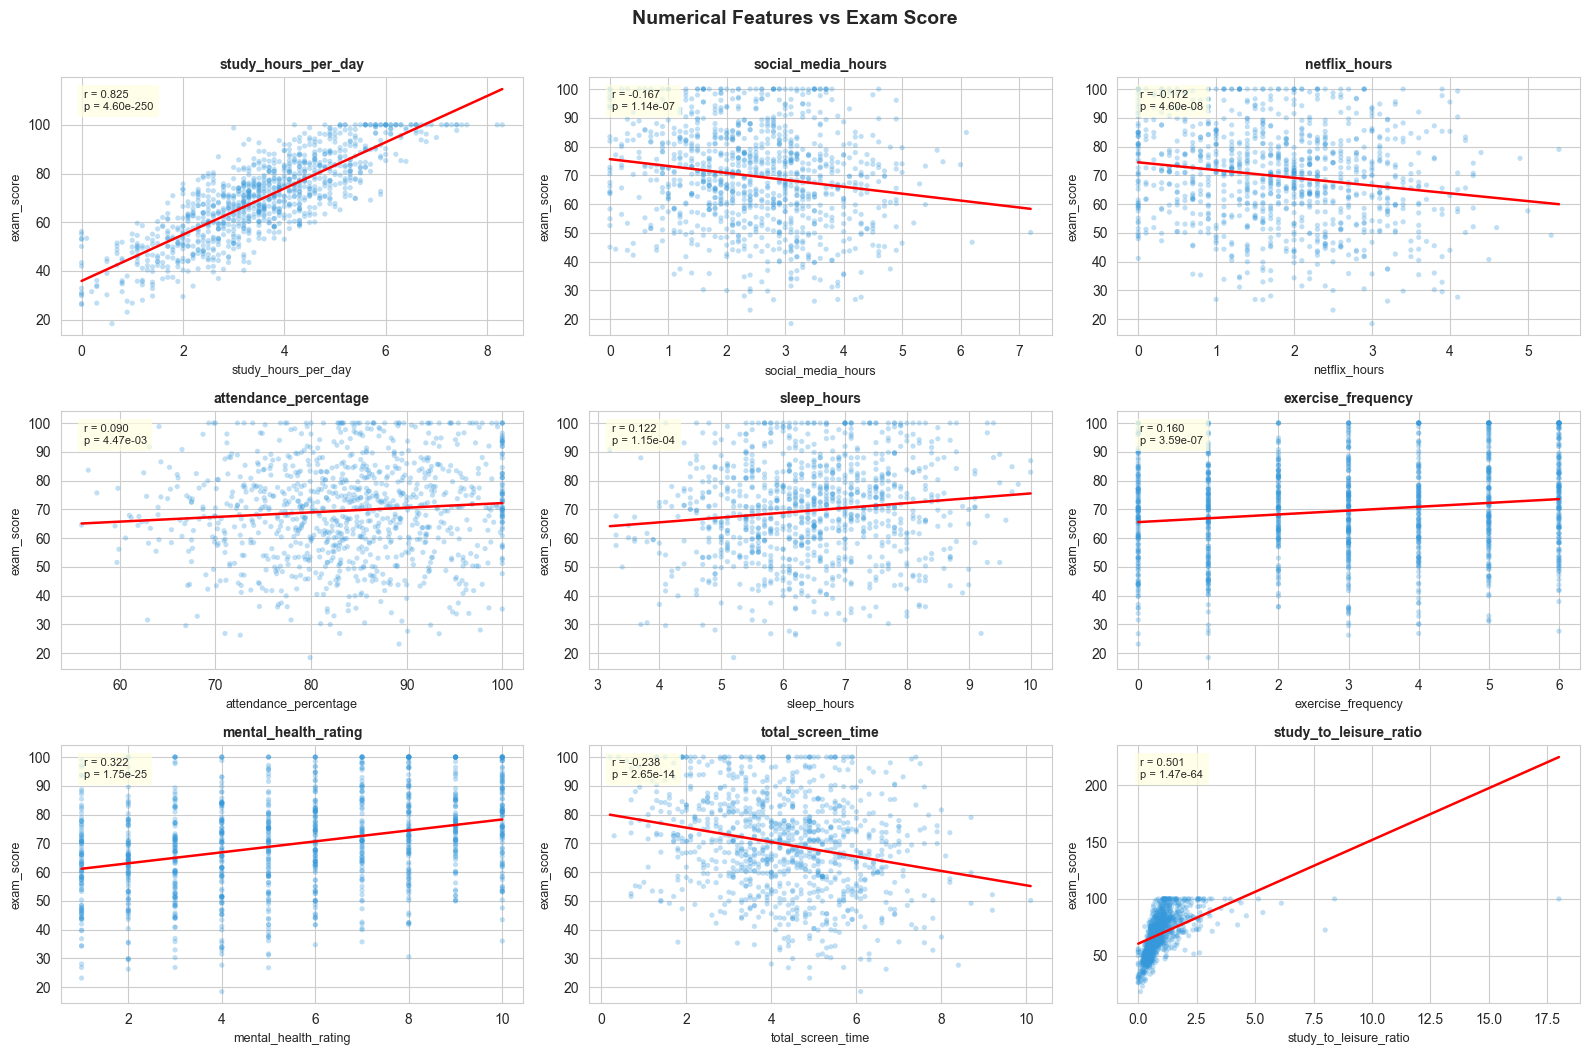

In [16]:
scatter_feats = [c for c in NUMERIC if c != "age"]   # age has no real signal
ncols, nrows = 3, (len(scatter_feats) + 2) // 3
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.5))
axes = axes.flatten()

for i, col in enumerate(scatter_feats):
    ax = axes[i]
    x = df[col].values
    y = df[TARGET].values
    ax.scatter(x, y, alpha=0.3, s=14, color="#3498db", edgecolors="none")
    m, b = np.polyfit(x, y, 1)
    xline = np.linspace(x.min(), x.max(), 100)
    ax.plot(xline, m*xline + b, color="red", lw=1.8)
    r, p = pearsonr(x, y)
    ax.set_title(col, fontweight="bold", fontsize=10)
    ax.set_xlabel(col, fontsize=9)
    ax.set_ylabel(TARGET, fontsize=9)
    ax.text(0.05, 0.95, f"r = {r:.3f}\np = {p:.2e}",
            transform=ax.transAxes, fontsize=8, va="top",
            bbox=dict(facecolor="lightyellow", alpha=0.7, edgecolor="none"))

for j in range(len(scatter_feats), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Numerical Features vs Exam Score", fontsize=14, fontweight="bold", y=1.00)
plt.tight_layout()
plt.savefig(FIG / "04_numerical_vs_target.png", dpi=120, bbox_inches="tight")
plt.show()

## 10. Bivariate Analysis — Categorical Features vs Exam Score

Box plots show the conditional distribution of the target per level. A
one-way ANOVA F-statistic tests whether at least one group mean differs;
group means are annotated above each box.

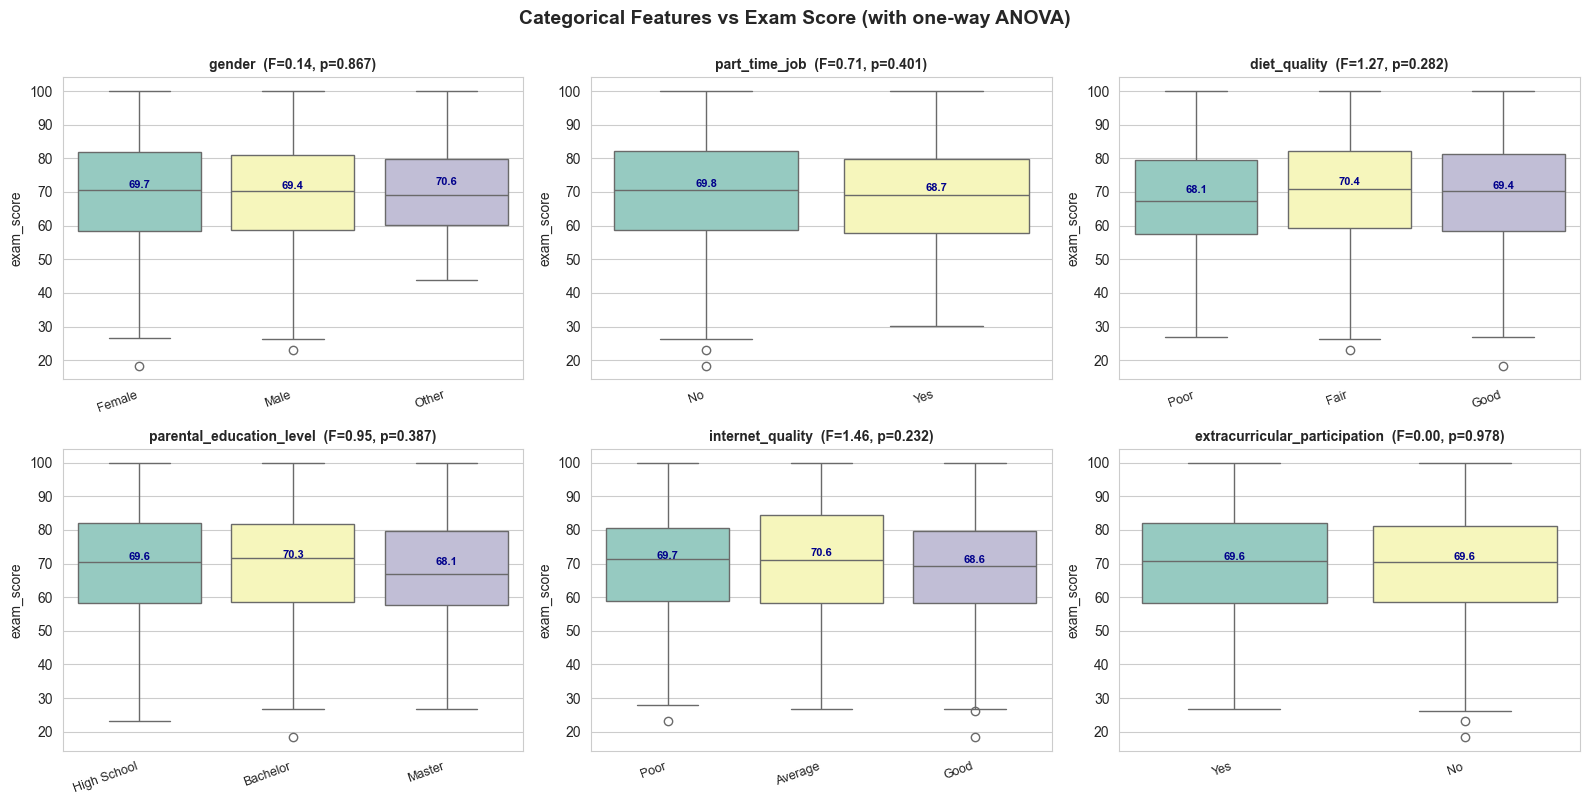


ANOVA summary (H₀: group means are equal):
  gender                            F =  0.142   p = 0.8674
  part_time_job                     F =  0.707   p = 0.4006
  diet_quality                      F =  1.266   p = 0.2824
  parental_education_level          F =  0.949   p = 0.3875
  internet_quality                  F =  1.463   p = 0.2320
  extracurricular_participation     F =  0.001   p = 0.9778


In [17]:
ncols, nrows = 3, (len(CATEGORICAL) + 2) // 3
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes = axes.flatten()
anova_results = []

for i, col in enumerate(CATEGORICAL):
    ax = axes[i]
    order = ORDER.get(col)
    sns.boxplot(data=df, x=col, y=TARGET, ax=ax, palette="Set3", order=order)
    means  = df.groupby(col)[TARGET].mean()
    groups = [df[df[col] == lvl][TARGET].values for lvl in df[col].unique()]
    f_stat, p_val = f_oneway(*groups)
    anova_results.append((col, f_stat, p_val))
    ax.set_title(f"{col}  (F={f_stat:.2f}, p={p_val:.3f})",
                 fontweight="bold", fontsize=10)
    ax.set_xlabel("")
    plt.setp(ax.get_xticklabels(), rotation=20, ha="right", fontsize=9)
    for tick, label in enumerate(ax.get_xticklabels()):
        val = label.get_text()
        if val in means.index:
            ax.text(tick, means[val] + 1.5, f"{means[val]:.1f}",
                    ha="center", fontsize=8, fontweight="bold", color="darkblue")

for j in range(len(CATEGORICAL), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Categorical Features vs Exam Score (with one-way ANOVA)",
             fontsize=14, fontweight="bold", y=1.00)
plt.tight_layout()
plt.savefig(FIG / "05_categorical_vs_target.png", dpi=120, bbox_inches="tight")
plt.show()

print("\nANOVA summary (H₀: group means are equal):")
for col, f, p in anova_results:
    flag = "  ***significant***" if p < 0.05 else ""
    print(f"  {col:32s}  F = {f:6.3f}   p = {p:.4f}{flag}")

## 11. Multivariate Analysis — Correlation Heatmap

A lower-triangular heatmap of pairwise Pearson correlations across all
numeric features and the target. This exposes both feature–target
relationships and feature–feature multicollinearity that could affect
linear models.

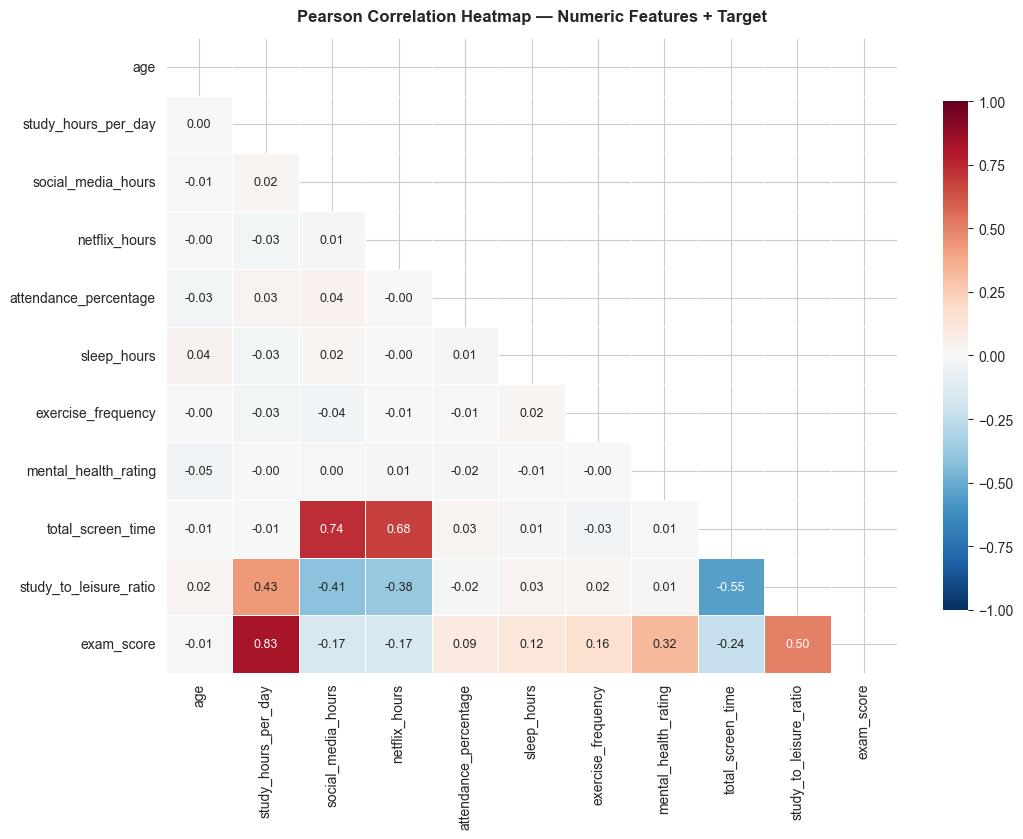

In [18]:
corr_cols = NUMERIC + [TARGET]
corr = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(11, 8.5))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            annot_kws={"size": 9}, cbar_kws={"shrink": 0.8})
ax.set_title("Pearson Correlation Heatmap — Numeric Features + Target",
             fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig(FIG / "06_correlation_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()

## 12. Ranked Correlations with the Target

A single, ranked view of how strongly each numeric feature relates to
`exam_score`. This is the most useful single chart for the report.

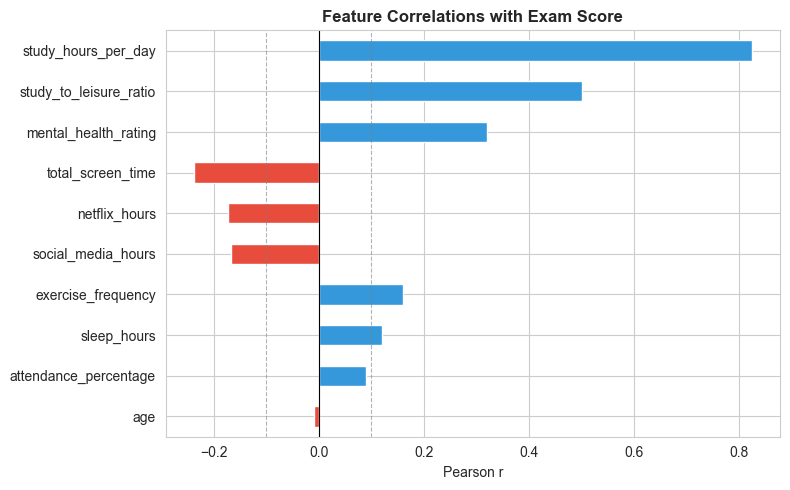

Sorted by |r|:
study_hours_per_day       0.825
study_to_leisure_ratio    0.501
mental_health_rating      0.322
total_screen_time        -0.238
netflix_hours            -0.172
social_media_hours       -0.167
exercise_frequency        0.160
sleep_hours               0.122
attendance_percentage     0.090
age                      -0.009


In [19]:
top_corr = corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#e74c3c" if v < 0 else "#3498db" for v in top_corr]
top_corr.plot(kind="barh", ax=ax, color=colors, edgecolor="white")
ax.axvline(0,    color="black", lw=0.8)
ax.axvline(0.1,  color="gray",  ls="--", lw=0.8, alpha=0.6)
ax.axvline(-0.1, color="gray",  ls="--", lw=0.8, alpha=0.6)
ax.set_title("Feature Correlations with Exam Score", fontweight="bold")
ax.set_xlabel("Pearson r")
plt.tight_layout()
plt.savefig(FIG / "07_target_correlations.png", dpi=120, bbox_inches="tight")
plt.show()

print("Sorted by |r|:")
print(top_corr.reindex(top_corr.abs().sort_values(ascending=False).index)
              .round(3).to_string())